In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import deque, defaultdict
import copy

Part1

In [ ]:
df = pd.read_csv("balanced_graph.csv")

adj = defaultdict(list)
for u, v, s in df.values:
    if s != 0:
        adj[u].append((v, s))
        adj[v].append((u, s))

label = {}
for start in adj:
    if start in label:
        continue
    label[start] = 1
    q = deque([start])
    while q:
        u = q.popleft()
        for v, s in adj[u]:
            expected = label[u] * s
            if v not in label:
                label[v] = expected
                q.append(v)

def infer(row):
    if row.sign != 0:
        return row.sign
    return 1 if label[row.u] == label[row.v] else -1

df["sign"] = df.apply(infer, axis=1)

df.to_csv('final_graph.csv', index=False, header=True)

Part2

In [3]:
def balance_test(G):
    super_nodes = {}
    
    for node1, node2, data in G.edges(data=True):
        if data['sign'] == 1:
            if node1 not in super_nodes and node2 not in super_nodes:
                super_nodes[node1] = [node1, node2]
                super_nodes[node2] = super_nodes[node1]
            
            elif node1 in super_nodes and node2 not in super_nodes:
                super_nodes[node1].append(node2)
                super_nodes[node2] = super_nodes[node1]
            
            elif node2 in super_nodes and node1 not in super_nodes:
                super_nodes[node2].append(node1)
                super_nodes[node1] = super_nodes[node2]
    

    contradictions = False
    for node1, node2, data in G.edges(data=True):
        if data['sign'] == -1:
            if super_nodes.get(node1) == super_nodes.get(node2):
                contradictions = True
                break
    
    return ('Balanced' if not contradictions else 'Unbalanced', super_nodes)



G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row['u'], row['v'], sign=row['sign'])
res, _ = balance_test(G)
print(f"network in part a is {res}")


graph_data_a = pd.read_csv("network_a.csv")

G_a = nx.Graph()

for _, row in graph_data_a.iterrows():
    G_a.add_edge(row['u'], row['v'], sign=row['sign'])
result, supernode = balance_test(G_a)
print(f"network a is {result}")
print(f"supernode is {supernode}")

graph_data_b = pd.read_csv("network_b.csv")

G_b = nx.Graph()

for _, row in graph_data_b.iterrows():
    G_b.add_edge(row['u'], row['v'], sign=row['sign'])
balanced, supernode = balance_test(G_b)
print(f"network b is {result}")
print(f"supernode is {supernode}")

graph_data_c = pd.read_csv("network_c.csv")

G_c = nx.Graph()

for _, row in graph_data_c.iterrows():
    G_c.add_edge(row['u'], row['v'], sign=row['sign'])
balanced, supernode = balance_test(G_c)
print(f"network c is {result}")
print(f"supernode is {supernode}")

graph_data_d = pd.read_csv("network_d.csv")

G_d = nx.Graph()

for _, row in graph_data_d.iterrows():
    G_d.add_edge(row['u'], row['v'], sign=row['sign'])
result, supernode = balance_test(G_d)
print(f"network d is {result}")
print(f"supernode is {supernode}")

graph_data_e = pd.read_csv("network_e.csv")

G_e = nx.Graph()

for _, row in graph_data_e.iterrows():
    G_e.add_edge(row['u'], row['v'], sign=row['sign'])
result, supernode = balance_test(G_e)
print(f"network e is {result}")
print(f"supernode is {supernode}")

graph_data_f = pd.read_csv("network_f.csv")

G_f = nx.Graph()
for _, row in graph_data_f.iterrows():
    G_f.add_edge(row['u'], row['v'], sign=row['sign'])
result, supernode = balance_test(G_f)
print(f"network f is {result}")
print(f"supernode is {supernode}")

graph_data_g = pd.read_csv("network_g.csv")

G_g = nx.Graph()

for _, row in graph_data_g.iterrows():
    G_g.add_edge(row['u'], row['v'], sign=row['sign'])
result, supernode = balance_test(G_g)
print(f"network g is {result}")
print(f"supernode is {supernode}")

graph_data_h = pd.read_csv("network_h.csv")

G_h = nx.Graph()

for _, row in graph_data_h.iterrows():
    G_h.add_edge(row['u'], row['v'], sign=row['sign'])
result, supernode = balance_test(G_h)
print(f"network h is {result}")
print(f"supernode is {supernode}")



network in part a is Balanced
network a is Balanced
supernode is {np.int64(0): [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(9), np.int64(27), np.int64(29), np.int64(15), np.int64(22), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(1), np.int64(12), np.int64(20), np.int64(8), np.int64(19), np.int64(24), np.int64(25), np.int64(13), np.int64(5), np.int64(26), np.int64(3), np.int64(11), np.int64(7), np.int64(30), np.int64(16)], np.int64(2): [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(9), np.int64(27), np.int64(29), np.int64(15), np.int64(22), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(1), np.int64(12), np.int64(20), np.int64(8), np.int64(19), np.int64(24), np.int64(25), np.int64(13), np.int64(5), np.int64(26), np.int64(3), np.int64(11), np.int64(7), np.int64(30), np.int64(16)], np.int64(4): [np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(9), np.int64(27), np.int64(29), np.int64(15), np.int64(22), np.in

Part3

Cluster 0: 5 nodes
Cluster 1: 5 nodes
Cluster 2: 4 nodes


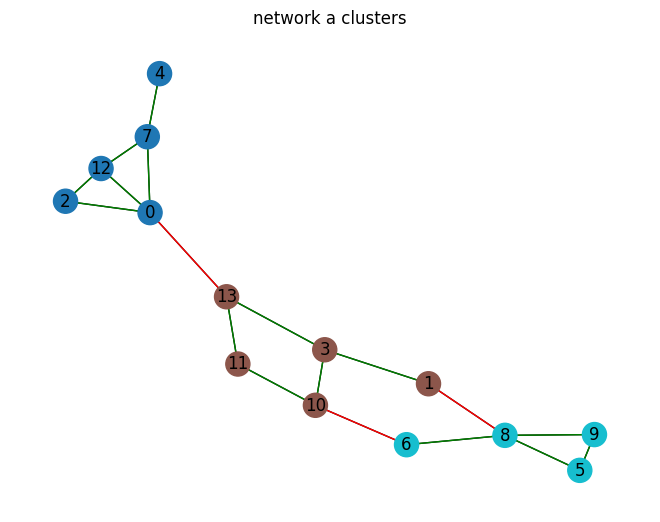

In [4]:
df_a = pd.read_csv("3/network_a.csv")
G_a = nx.from_pandas_edgelist(df_a, "u", "v", edge_attr="sign")
G_pos = nx.Graph(
    (u, v) for u, v, d in G_a.edges(data=True) if d["sign"] > 0
)

clusters = list(nx.connected_components(G_pos))

for i, c in enumerate(clusters):
    print(f"Cluster {i}: {len(c)} nodes")


pos = nx.spring_layout(G_a, seed=42)

node_cluster = {}
for i, c in enumerate(clusters):
    for n in c:
        node_cluster[n] = i

node_colors = [node_cluster.get(n, -1) for n in G_a.nodes()]

nx.draw(
    G_a, pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=300,
    with_labels=True
)

edge_colors = ["green" if G_a[u][v]["sign"] > 0 else "red" for u, v in G_a.edges()]
nx.draw_networkx_edges(G_a, pos, edge_color=edge_colors)
plt.title("network a clusters")

plt.show()





Cluster 0: 5 nodes
Cluster 1: 5 nodes
Cluster 2: 5 nodes
Cluster 3: 5 nodes


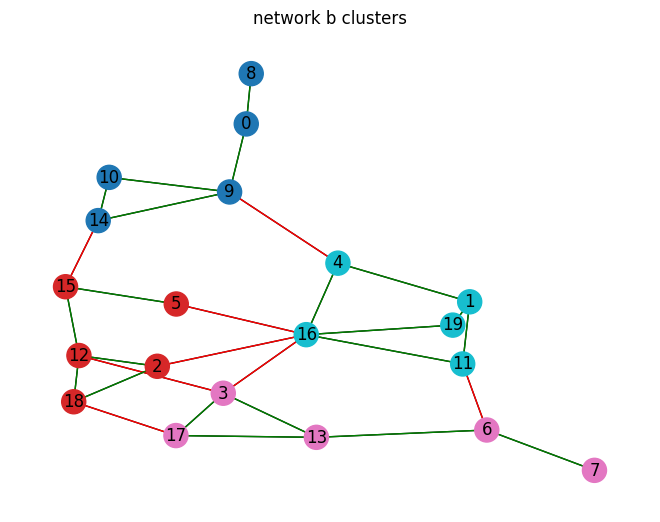

In [5]:
df_b = pd.read_csv("3/network_b.csv")
G_b = nx.from_pandas_edgelist(df_b, "u", "v", edge_attr="sign")
G_pos = nx.Graph(
    (u, v) for u, v, d in G_b.edges(data=True) if d["sign"] > 0
)

clusters = list(nx.connected_components(G_pos))

for i, c in enumerate(clusters):
    print(f"Cluster {i}: {len(c)} nodes")


pos = nx.spring_layout(G_b, seed=42)

node_cluster = {}
for i, c in enumerate(clusters):
    for n in c:
        node_cluster[n] = i

node_colors = [node_cluster.get(n, -1) for n in G_b.nodes()]

nx.draw(
    G_b, pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=300,
    with_labels=True
)

edge_colors = ["green" if G_b[u][v]["sign"] > 0 else "red" for u, v in G_b.edges()]
nx.draw_networkx_edges(G_b, pos, edge_color=edge_colors)
plt.title("network b clusters")

plt.show()

Cluster 0: 8 nodes
Cluster 1: 8 nodes
Cluster 2: 7 nodes
Cluster 3: 7 nodes


Text(0.5, 1.0, 'network c clusters')

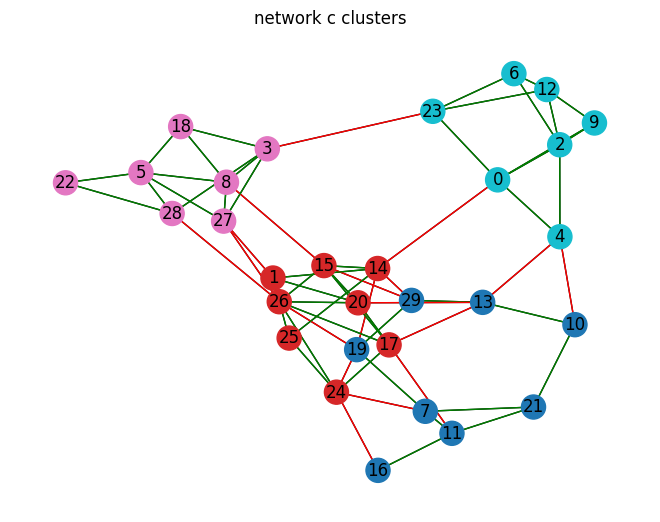

In [ ]:
df_c = pd.read_csv("3/network_c.csv")
G_c = nx.from_pandas_edgelist(df_c, "u", "v", edge_attr="sign")
G_pos = nx.Graph(
    (u, v) for u, v, d in G_c.edges(data=True) if d["sign"] > 0
)

clusters = list(nx.connected_components(G_pos))

for i, c in enumerate(clusters):
    print(f"Cluster {i}: {len(c)} nodes")


pos = nx.spring_layout(G_c, seed=42)

node_cluster = {}
for i, c in enumerate(clusters):
    for n in c:
        node_cluster[n] = i

node_colors = [node_cluster.get(n, -1) for n in G_c.nodes()]

nx.draw(
    G_c, pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=300,
    with_labels=True
)

edge_colors = ["green" if G_c[u][v]["sign"] > 0 else "red" for u, v in G_c.edges()]
nx.draw_networkx_edges(G_c, pos, edge_color=edge_colors)
plt.title("network c clusters")

Cluster 0: 7 nodes
Cluster 1: 7 nodes
Cluster 2: 7 nodes
Cluster 3: 7 nodes
Cluster 4: 6 nodes
Cluster 5: 6 nodes


Text(0.5, 1.0, 'network d clusters')

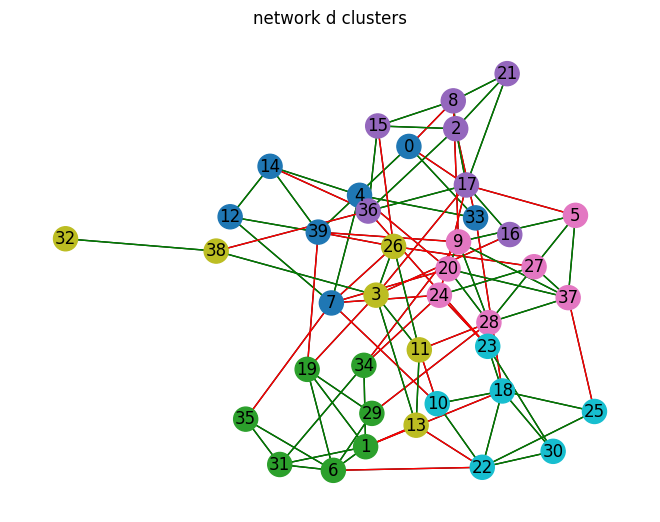

In [7]:
df_d = pd.read_csv("3/network_d.csv")
G_d = nx.from_pandas_edgelist(df_d, "u", "v", edge_attr="sign")
G_pos = nx.Graph(
    (u, v) for u, v, d in G_d.edges(data=True) if d["sign"] > 0
)

clusters = list(nx.connected_components(G_pos))

for i, c in enumerate(clusters):
    print(f"Cluster {i}: {len(c)} nodes")


pos = nx.spring_layout(G_d, seed=42)

node_cluster = {}
for i, c in enumerate(clusters):
    for n in c:
        node_cluster[n] = i

node_colors = [node_cluster.get(n, -1) for n in G_d.nodes()]

nx.draw(
    G_d, pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=300,
    with_labels=True
)

edge_colors = ["green" if G_d[u][v]["sign"] > 0 else "red" for u, v in G_d.edges()]
nx.draw_networkx_edges(G_d, pos, edge_color=edge_colors)
plt.title("network d clusters")

Cluster 0: 8 nodes
Cluster 1: 8 nodes
Cluster 2: 8 nodes
Cluster 3: 8 nodes
Cluster 4: 7 nodes
Cluster 5: 7 nodes
Cluster 6: 7 nodes
Cluster 7: 7 nodes


Text(0.5, 1.0, 'network e clusters')

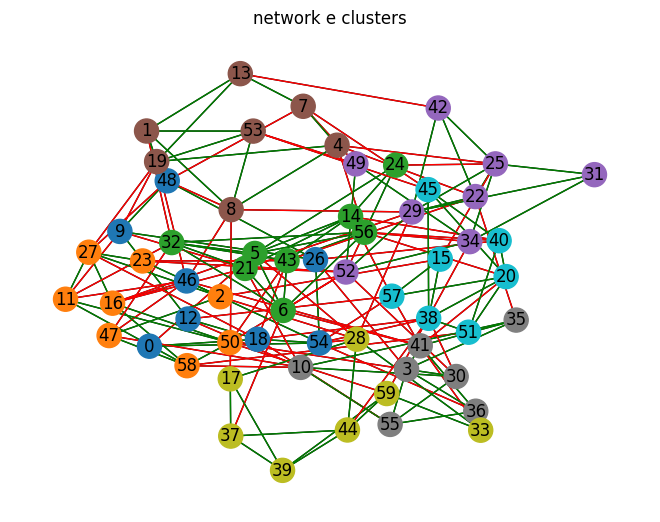

In [8]:
df_e = pd.read_csv("3/network_e.csv")
G_e = nx.from_pandas_edgelist(df_e, "u", "v", edge_attr="sign")
G_pos = nx.Graph(
    (u, v) for u, v, d in G_e.edges(data=True) if d["sign"] > 0
)

clusters = list(nx.connected_components(G_pos))

for i, c in enumerate(clusters):
    print(f"Cluster {i}: {len(c)} nodes")


pos = nx.spring_layout(G_e, seed=42)

node_cluster = {}
for i, c in enumerate(clusters):
    for n in c:
        node_cluster[n] = i

node_colors = [node_cluster.get(n, -1) for n in G_e.nodes()]

nx.draw(
    G_e, pos,
    node_color=node_colors,
    cmap=plt.cm.tab10,
    node_size=300,
    with_labels=True
)

edge_colors = ["green" if G_e[u][v]["sign"] > 0 else "red" for u, v in G_e.edges()]
nx.draw_networkx_edges(G_e, pos, edge_color=edge_colors)
plt.title("network e clusters")

Part4

In [9]:
def compute_line_index(G, alpha=0.5):
    clusters = {node: random.randint(1, 4) for node in G.nodes()}
    
    P = sum(1 for node1, node2, data in G.edges(data=True) if data['sign'] == 1 and clusters[node1] != clusters[node2])
    N = sum(1 for node1, node2, data in G.edges(data=True) if data['sign'] == -1 and clusters[node1] != clusters[node2])
    
    line_index = alpha * P + (1 - alpha) * N
    return line_index, clusters


def compute_line_index_with_clusters(G, clusters, alpha=0.5):
    P = sum(
        1 for u, v, d in G.edges(data=True)
        if d["sign"] == 1 and clusters[u] != clusters[v]
    )
    N = sum(
        1 for u, v, d in G.edges(data=True)
        if d["sign"] == -1 and clusters[u] != clusters[v]
    )
    return alpha * P + (1 - alpha) * N


def improve_clustering(G, clusters, k=4, alpha=0.5, max_iter=20):
    best_clusters = clusters.copy()
    best_score = compute_line_index_with_clusters(G, best_clusters, alpha)

    for _ in range(max_iter):
        improved = False

        for node in G.nodes():
            current_cluster = best_clusters[node]

            for c in range(1, k + 1):
                if c == current_cluster:
                    continue

                trial = best_clusters.copy()
                trial[node] = c
                score = compute_line_index_with_clusters(G, trial, alpha)

                if score < best_score:
                    best_score = score
                    best_clusters = trial
                    improved = True

        if not improved:
            break

    return best_score, best_clusters


data = pd.read_csv("network_line_index.csv")
G = nx.Graph()
for _, row in data.iterrows():
    G.add_edge(row['u'], row['v'], sign=row['sign'])
line_index, clusters = compute_line_index(G)
print(f"Line Index: {line_index}")

line_index_final, improved_clusters = improve_clustering(
    G, clusters, k=4, alpha=0.5
)
print(f"Improved Line Index: {line_index_final}")


Line Index: 59.0
Improved Line Index: 0.0


Part5

In [10]:
df = pd.read_csv("network_transitivity.csv")
G = nx.from_pandas_edgelist(df, "source", "target", create_using=nx.DiGraph())
transitive = []
missing = []

for i, j in G.edges():
    for _, k in G.out_edges(j):
        if i == k:
            continue
        if G.has_edge(i, k):
            transitive.append((i, j, k))
        else:
            missing.append((i, j, k))
num_transitive = len(transitive)
num_missing = len(missing)
num_total = num_transitive + num_missing

print("Transitive triples:", num_transitive)
print("Missing edges:", num_missing)

transitivity_ratio = num_transitive / num_total if num_total > 0 else 0
print("Transitivity ratio:", transitivity_ratio)

TC = nx.transitive_closure(G)
added_edges = set(TC.edges()) - set(G.edges())
print(f"number of added edges is {len(added_edges)}")
print("Total edges after closure:", TC.number_of_edges())

Transitive triples: 70
Missing edges: 3207
Transitivity ratio: 0.021361000915471468
number of added edges is 38186
Total edges after closure: 39006
